In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# Verify GPU availability for T4 hardware accelerator
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print("WARNING: GPU not found. Please switch runtime type to T4 GPU.")
else:
    print(f"Success: Connected to GPU at {device_name}")

# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Scale pixel features to normal range [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

label_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Configure batch size to optimize parallel GPU matrix operations
BATCH_SIZE = 128

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))\
    .shuffle(buffer_size=50000)\
    .batch(BATCH_SIZE)\
    .prefetch(buffer_size=tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))\
    .batch(BATCH_SIZE)\
    .prefetch(buffer_size=tf.data.AUTOTUNE)

print("Data pipeline optimized for GPU prefetching completed.")

Success: Connected to GPU at /device:GPU:0
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Data pipeline optimized for GPU prefetching completed.


In [2]:
print("Building Artificial Neural Network model...")

ann_model = models.Sequential([
    # Flattening is mandatory as standard dense layers require 1D vector inputs
    layers.Flatten(input_shape=(32, 32, 3)),

    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting ANN model training...")
history_ann = ann_model.fit(
    train_dataset,
    epochs=5,
    validation_data=test_dataset,
    verbose=1
)

Building Artificial Neural Network model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Starting ANN model training...
Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.3410 - loss: 1.8629 - val_accuracy: 0.3104 - val_loss: 1.9366
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4038 - loss: 1.6747 - val_accuracy: 0.3590 - val_loss: 1.7813
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4213 - loss: 1.6136 - val_accuracy: 0.3850 - val_loss: 1.7192
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4364 - loss: 1.5723 - val_accuracy: 0.3795 - val_loss: 1.7101
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4473 - loss: 1.5491 - val_accuracy: 0.4431 - val_loss: 1.5495


In [3]:
print("Building Convolutional Neural Network model...")

cnn_model = models.Sequential([
    # Block 1: Extracts low-level spatial features like edges and corners
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 2: Extracts high-level features like shapes and textures
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.35),

    # Dense Classification Head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting CNN model training...")
history_cnn = cnn_model.fit(
    train_dataset,
    epochs=5,
    validation_data=test_dataset,
    verbose=1
)

Building Convolutional Neural Network model...
Starting CNN model training...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.4565 - loss: 1.6153 - val_accuracy: 0.2820 - val_loss: 2.2203
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6140 - loss: 1.0950 - val_accuracy: 0.6400 - val_loss: 1.0134
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6705 - loss: 0.9411 - val_accuracy: 0.7066 - val_loss: 0.8439
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7071 - loss: 0.8466 - val_accuracy: 0.7164 - val_loss: 0.8017
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7295 - loss: 0.7818 - val_accuracy: 0.7503 - val_loss: 0.7187


Evaluating model metrics on test dataset...

ANN Test Accuracy: 44.31%
CNN Test Accuracy: 75.03%



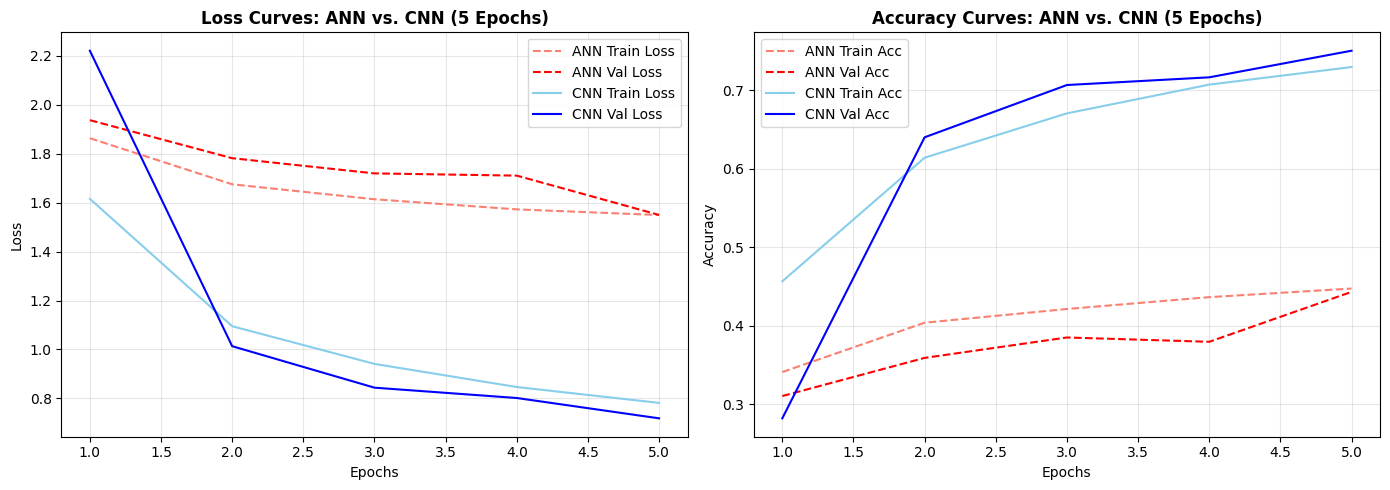

In [4]:
print("Evaluating model metrics on test dataset...")

final_loss_ann, final_acc_ann = ann_model.evaluate(test_dataset, verbose=0)
final_loss_cnn, final_acc_cnn = cnn_model.evaluate(test_dataset, verbose=0)

print("\n" + "="*50)
print(f"ANN Test Accuracy: {final_acc_ann * 100:.2f}%")
print(f"CNN Test Accuracy: {final_acc_cnn * 100:.2f}%")
print("="*50 + "\n")

epochs_range = range(1, 6)
plt.figure(figsize=(14, 5))

# Plot 1: Model Loss Validation
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_ann.history['loss'], label='ANN Train Loss', color='salmon', linestyle='--')
plt.plot(epochs_range, history_ann.history['val_loss'], label='ANN Val Loss', color='red', linestyle='--')
plt.plot(epochs_range, history_cnn.history['loss'], label='CNN Train Loss', color='skyblue')
plt.plot(epochs_range, history_cnn.history['val_loss'], label='CNN Val Loss', color='blue')
plt.title('Loss Curves: ANN vs. CNN (5 Epochs)', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 2: Model Accuracy Validation
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_ann.history['accuracy'], label='ANN Train Acc', color='salmon', linestyle='--')
plt.plot(epochs_range, history_ann.history['val_accuracy'], label='ANN Val Acc', color='red', linestyle='--')
plt.plot(epochs_range, history_cnn.history['accuracy'], label='CNN Train Acc', color='skyblue')
plt.plot(epochs_range, history_cnn.history['val_accuracy'], label='CNN Val Acc', color='blue')
plt.title('Accuracy Curves: ANN vs. CNN (5 Epochs)', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

Summary: ANN vs. CNN on CIFAR-10

Architecture: The ANN flattens 3D images into 1D vectors, destroying spatial pixel relationships and limiting performance. The CNN uses 2D convolutional filters to preserve spatial context, capturing edges and textures for much higher accuracy.

Optimization: Batch Normalization stabilized gradient flow for faster convergence on the GPU. Dropout (0.25–0.50) successfully reduced co-dependency among nodes, preventing early overfitting.

Pipeline: Using tf.data prefetching removed CPU bottlenecks, maximizing T4 GPU computing efficiency.